
Sc_R1s(r) =
+188.1829 * exp(-21.7237 r)
+132.2797 * r * exp(-18.5964 r)
+0.4431 * r * exp(-8.5331 r)
+425.9204 * r^2 * exp(-26.6635 r)
+0.0885 * r^2 * exp(-6.3629 r)
-0.0213 * r^2 * exp(-4.4087 r)
+0.0014 * r^2 * exp(-2.9836 r)
-2.2873 * r^3 * exp(-10.0558 r)
-0.0000 * r^3 * exp(-1.7339 r)
+0.0000 * r^3 * exp(-1.1548 r)
-0.0000 * r^3 * exp(-0.8074 r)

Sc_R2s(r) =
-55.1465 * exp(-21.7237 r)
-285.7301 * r * exp(-18.5964 r)
+247.6527 * r * exp(-8.5331 r)
-64.0119 * r^2 * exp(-26.6635 r)
-23.5490 * r^2 * exp(-6.3629 r)
-0.4911 * r^2 * exp(-4.4087 r)
+0.0547 * r^2 * exp(-2.9836 r)
-241.3325 * r^3 * exp(-10.0558 r)
-0.0005 * r^3 * exp(-1.7339 r)
+0.0001 * r^3 * exp(-1.1548 r)
-0.0000 * r^3 * exp(-0.8074 r)

Sc_R3s(r) =
-19.4283 * exp(-21.7237 r)
-114.5893 * r * exp(-18.5964 r)
+101.6150 * r * exp(-8.5331 r)
-52.1670 * r^2 * exp(-26.6635 r)
-31.8311 * r^2 * exp(-6.3629 r)
-43.0555 * r^2 * exp(-4.4087 r)
-12.3498 * r^2 * exp(-2.9836 r)
+292.1062 * r^3 * exp(-10.0558 r)
-0.0114 * r^3 * exp(-1.

/tmp/ipykernel_304/196544021.py:128: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.041840       7.246464e-02       5.998636e-01   
1       0.05           0.041840       7.245310e-02       5.985164e-01   
2       0.10           0.041837       7.241847e-02       5.944961e-01   
3       0.15           0.041833       7.236075e-02       5.878649e-01   
4       0.20           0.041828       7.227994e-02       5.787236e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000002       1.753961e-07       2.187020e-08   
1997   99.85           0.000002       1.746211e-07       2.177352e-08   
1998   99.90           0.000002       1.738488e-07       2.167717e-08   
1999   99.95           0.000002       1.730790e-07       2.158115e-08   
2000  100.00           0.000002       1.723119e-07       2.148545e-08   

      J_2p_one_electron  J_3p_one_electron  J_3d_one_electron  \
0          8.467041e-02       3.038099e-01       3.100442e

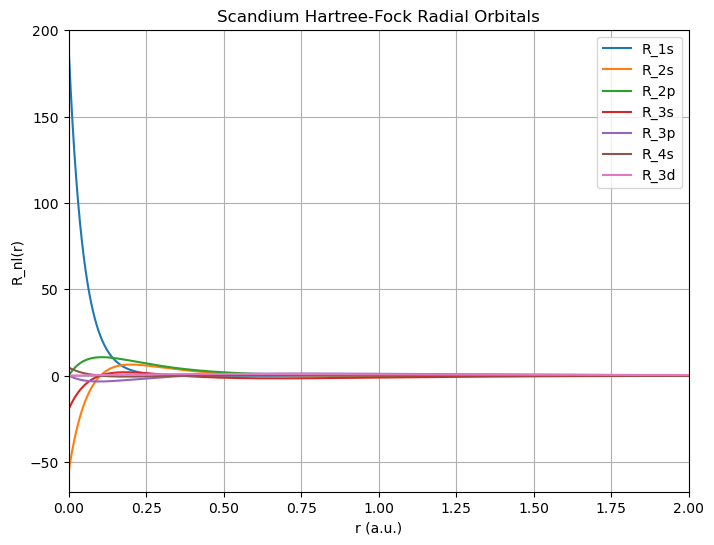

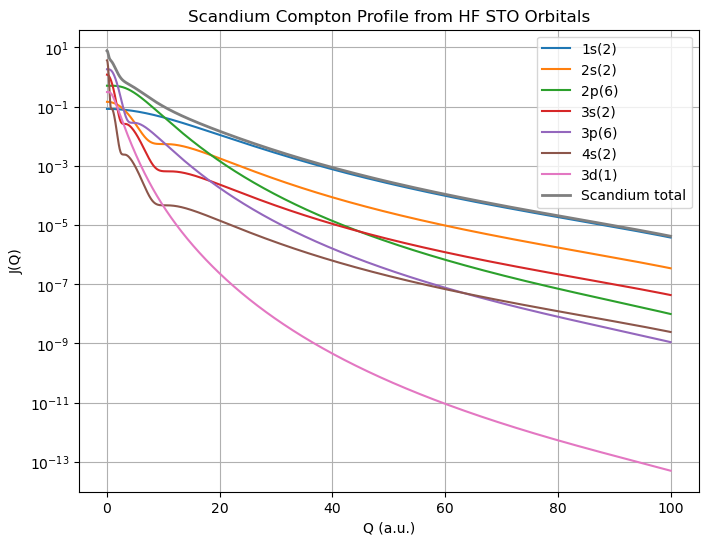

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Scandium Hartree-Fock STO data
# Sc: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(1) 4s(2)
# =====================================================

scandium_1s = [
    (1,21.7237, 0.929286),
    (2,18.5964, 0.076816),
    (2, 8.5331, 0.001804),
    (3,26.6635, 0.010320),
    (3, 6.3629, 0.000323),
    (3, 4.4087,-0.000281),
    (3, 2.9836, 0.000073),
    (4,10.0558,-0.000626),
    (4, 1.7339,-0.000024),
    (4, 1.1548, 0.000018),
    (4, 0.8074,-0.000007),
]

scandium_2s = [
    (1,21.7237,-0.272325),
    (2,18.5964,-0.165926),
    (2, 8.5331, 1.008339),
    (3,26.6635,-0.001551),
    (3, 6.3629,-0.085949),
    (3, 4.4087,-0.006473),
    (3, 2.9836, 0.002830),
    (4,10.0558,-0.066049),
    (4, 1.7339,-0.000346),
    (4, 1.1548, 0.000234),
    (4, 0.8074,-0.000082),
]

scandium_3s = [
    (1,21.7237,-0.095941),
    (2,18.5964,-0.066543),
    (2, 8.5331, 0.413734),
    (3,26.6635,-0.001264),
    (3, 6.3629,-0.116177),
    (3, 4.4087,-0.567549),
    (3, 2.9836,-0.638451),
    (4,10.0558, 0.079945),
    (4, 1.7339,-0.008505),
    (4, 1.1548, 0.002704),
    (4, 0.8074,-0.000727),
]

scandium_4s = [
    (1,21.7237, 0.022762),
    (2,18.5964, 0.016069),
    (2, 8.5331,-0.100051),
    (3,26.6635, 0.000291),
    (3, 6.3629,-0.031040),
    (3, 4.4087, 0.162661),
    (3, 2.9836, 0.169417),
    (4,10.0558,-0.022175),
    (4, 1.7339,-0.303304),
    (4, 1.1548,-0.526693),
    (4, 0.8074,-0.286745),
]

scandium_2p = [
    (2,31.2091, 0.001156),
    (2,12.6896, 0.341553),
    (2, 6.5469, 0.415271),
    (2, 2.7945, 0.003830),
    (3,10.0778, 0.296715),
    (3, 2.3661,-0.000849),
    (3, 1.4540, 0.000109),
]

scandium_3p = [
    (2,31.2091,-0.000287),
    (2,12.6896,-0.074761),
    (2, 6.5469,-0.457411),
    (2, 2.7945, 0.888499),
    (3,10.0778,-0.013956),
    (3, 2.3661, 0.311816),
    (3, 1.4540, 0.021060),
]

scandium_3d = [
    (3,9.8549, 0.015123),
    (3,4.8498, 0.159653),
    (3,2.9200, 0.359860),
    (3,1.7389, 0.434880),
    (3,1.0594, 0.199419),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Scandium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, scandium_1s)
R2s = R_nl(r, scandium_2s)
R3s = R_nl(r, scandium_3s)
R4s = R_nl(r, scandium_4s)
R2p = R_nl(r, scandium_2p)
R3p = R_nl(r, scandium_3p)
R3d = R_nl(r, scandium_3d)


print_R_formula(scandium_1s, "Sc_R1s")
print_R_formula(scandium_2s, "Sc_R2s")
print_R_formula(scandium_3s, "Sc_R3s")
print_R_formula(scandium_3p, "Sc_R4s")
print_R_formula(scandium_2p, "Sc_R2p")
print_R_formula(scandium_3p, "Sc_R3p")
print_R_formula(scandium_3d, "Sc_R3d")
# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_2s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

# Scandium has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(1) 4s(2)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + J_3d + 2*J_4s

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(2)": 2*J_4s,
    "J_3d(1)": J_3d,
    "J_total_scandium": J_total
    })
print(table)
table.to_csv("Scandium_HF_Compton_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Scandium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, J_3d, label="3d(1)")
plt.plot(Q, J_total, label="Scandium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Scandium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()